### 1. 任務目標 (Goal)

開發一個 Jupyter Notebook 分析流程：利用 **水利署河川圖資** 建立多級警戒緩衝區，結合 **消防署避難收容所資料**（政府開放平台 CSV），評估各行政區的避難所洪災風險與收容量缺口。

### 2. 資料來源 (Data Sources)

A. 河川資料 — 水利署
河川面（Polygon）直接下載：

B. 避難收容所資料 — 消防署（政府開放平台）
從政府開放資料平台下載避難收容處所 CSV：直接使用前週已清理過之資料

C. 鄉鎮市區界 — 國土測繪中心
用於分區統計與地圖背景：

In [ ]:
import geopandas as gpd
import pandas as pd
from urllib.parse import quote
import os
from dotenv import load_dotenv

load_dotenv()

 # 河川資料 — 水利署
rivers = gpd.read_file('DATA_RIVER_PATH')

 # 避難收容所資料 — 消防署（政府開放平台）
shelters_csv = pd.read_csv('DATA_SHELTER_PATH')
shelters = gpd.GeoDataFrame(
    shelters_csv,
    geometry=gpd.points_from_xy(shelters_csv['經度'], shelters_csv['緯度']),
    crs='EPSG:4326'
)

 # 鄉鎮市區界 — 國土測繪中心
url = 'https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/' + quote('鄉(鎮、市、區)界線1140318.zip')
townships = gpd.read_file(url)

### 3. 核心要求 (Requirements)

A. 資料載入與清理 (Data Ingestion & Cleaning)

1. 讀取水利署河川面 Shapefile → 檢查 CRS（應為 EPSG:3826）
2. 讀取消防署避難所 CSV → 轉換至 **EPSG:3826**
3. 讀取鄉鎮界 → 轉換至 **EPSG:3826**

In [ ]:
print('river CRS  :', rivers.crs)

print('shelters CRS  :', shelters.crs)
shelters = shelters.to_crs(epsg=3826)
print('shelters fixed CRS  :', shelters.crs)

print('townships CRS  :', townships.crs)
townships = townships.to_crs(epsg=3826)
print('townships fixed CRS  :', townships.crs)

### B. 多級緩衝區分析 (Multi-Buffer Risk Zoning)

1. **三級河川警戒緩衝區**：
    - 從 `.env` 讀取參數：`BUFFER_HIGH=500`、`BUFFER_MED=1000`、`BUFFER_LOW=2000`（單位：公尺）
    - 建立三層緩衝區：**高風險（500m）/ 中風險（1km）/ 低風險（2km）**
    - 必須在 EPSG:3826 下做 buffer（Lab 1 的教訓）

In [ ]:
b_high = os.getenv('BUFFER_HIGH')
b_med = os.getenv('BUFFER_MED')
b_low = os.getenv('BUFFER_LOW')

In [ ]:
river_union = rivers.dissolve()

buffer_high = river_union.buffer(int(b_high))
buffer_med = river_union.buffer(int(b_med))
buffer_low = river_union.buffer(int(b_low))

# 建立buffer gdf 用於sjoin
buffers = [
    (buffer_high, 'High'),
    (buffer_med, 'Medium'),
    (buffer_low, 'Low')
]

2. **空間連接 (Spatial Join)**：
    - `gpd.sjoin()` 找出各級緩衝區內的避難所
    - 標記每個避難所的風險等級：高 / 中 / 低 / 安全
    - 處理一對多問題：若一個避難所同時落在多個緩衝區，取最高風險等級

In [ ]:
shelters['risk_level'] = 'Safe'
shelters['risk_score'] = 0

# 由低風險往高風險覆蓋，確保 "Highest wins"
risk_map = {'Low': 1, 'Medium': 2, 'High': 3}

for geom, level in reversed(buffers): # 從 Low 到 High
    mask = shelters.geometry.within(geom.iloc[0])
    shelters.loc[mask, 'risk_level'] = level
    shelters.loc[mask, 'risk_score'] = risk_map[level]

# 將避難所與鄉鎮界線結合，以利後續分組
shelters_with_town = gpd.sjoin(shelters, townships, how="left", predicate="within")

### C. 收容量缺口分析 (Capacity Gap Analysis)

這是跟 Lab 的關鍵差異——不只看「哪些避難所在風險區」，還要回答實際問題：

1. **分區統計**：按鄉鎮市區彙總
    - 各區高/中/低風險避難所數量
    - 各區風險區內的總收容人數
    - 各區安全避難所的總收容人數
2. **缺口判斷**：
    - 哪些行政區的安全避難所收容量不足（安全區收容量 < 風險區內常住人口的一定比例）？
    - 產出一份 **風險最高的 Top 10 行政區** 排名

In [ ]:
# 依鄉鎮分組統計
township_stats = shelters_with_town.groupby('TOWNNAME').agg({
    'risk_level': lambda x: (x != 'Safe').sum(), # 計算有風險的避難所數量
    'capacity': 'sum',
    'risk_score': 'mean' # 平均風險得分作為排序依據
}).rename(columns={'risk_level': 'at_risk_count'})

# 找出前 10 名最危險鄉鎮 (依據受威脅數量與容量排序)
top_10_towns = township_stats.sort_values(by=['at_risk_count', 'capacity'], ascending=False).head(10)
print(top_10_towns)

### D. 視覺化 (Visualization)

1. **互動式風險地圖**（`.explore()` 或 `folium`）：
    - 河川面（藍色）
    - 三級緩衝區（紅/橙/黃，半透明）
    - 避難所依風險等級著色：紅 = 高風險、橙 = 中風險、黃 = 低風險、綠 = 安全
    - 鄉鎮界作為背景
    - 點擊避難所可顯示名稱、收容人數、風險等級

In [ ]:
import folium

shelters_with_town = shelters_with_town.rename(columns={
    '預計收容人數': 'capacity',
    '避難收容處所名稱': 'name'
})

# 製作互動式地圖
m = folium.Map(location=[23.6, 121], zoom_start=7, tiles="cartodbpositron")

# 鄉鎮界背景
townships = townships.to_crs(epsg=4326)
folium.GeoJson(
    townships,
    name="Townships",
    style_function=lambda x: {
        "fillOpacity": 0,
        "color": "black",
        "weight": 0.5
    }
).add_to(m)


# 河川
rivers = rivers.to_crs(epsg=4326)
folium.GeoJson(
    rivers,
    name="Rivers",
    style_function=lambda x: {
        "color": "blue",
        "weight": 2
    }
).add_to(m)

# buffer
buffer_colors = {
    "High": "red",
    "Medium": "orange",
    "Low": "yellow"
}

buffer_distance = {
    "High": "500m",
    "Medium": "1km",
    "Low": "2km"
}

for geom_series, level in buffers:

    geom = geom_series.iloc[0]   # 取出真正的 shapely geometry

    buffer_gdf = gpd.GeoDataFrame(
        {"risk":[level]},
        geometry=[geom],
        crs=3826
    ).to_crs(epsg=4326)

    folium.GeoJson(
        buffer_gdf,
        name=f"{level} Risk Buffer ({buffer_distance[level]})",
        style_function=lambda x, level=level: {
            "fillColor": buffer_colors[level],
            "color": buffer_colors[level],
            "fillOpacity": 0.25,
            "weight": 0
        }
    ).add_to(m)


colors = {'High': 'red', 'Medium': 'orange', 'Low': 'yellow', 'Safe': 'green'}

for _, row in shelters_with_town.to_crs(epsg=4326).iterrows():
    popup_html = f"""
    <b>Shelter:</b> {row.get('name','N/A')}<br>
    <b>Capacity:</b> {row.get('capacity','N/A')}<br>
    <b>Risk:</b> {row.get('risk_level','N/A')}
    """

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        color=colors[row['risk_level']],
        fill=True,
        fill_color=colors[row['risk_level']],
        fill_opacity=0.9,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(m)
    
folium.LayerControl().add_to(m)

m.save('flood_risk_map_v2.html')

2. **靜態統計圖**：
    - 長條圖：Top 10 高風險行政區的避難所數量 vs. 收容量
    - 另存 `risk_map.png`

In [ ]:
import matplotlib.pyplot as plt
import matplotlib

# 設定字型
matplotlib.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# 繪製前十大風險鄉鎮長條圖
top_10_towns['at_risk_count'].plot(kind='bar', color='salmon', figsize=(10, 6))
plt.title('Top 10 At-Risk Townships (Shelter Count)')
plt.ylabel('Number of At-Risk Shelters')
plt.show()

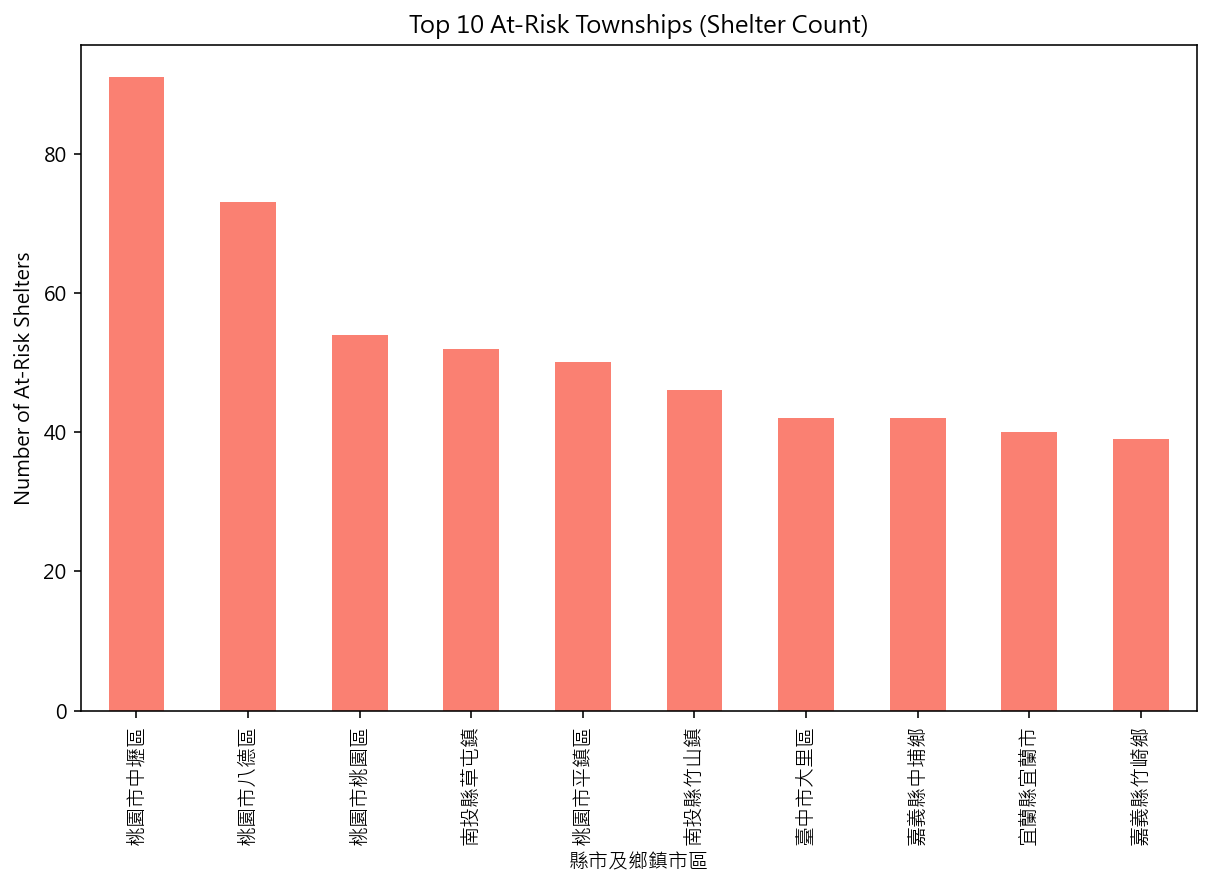

### 匯出結果

In [ ]:
# 匯出結果
output_columns = ['geometry', 'risk_level', 'capacity', 'TOWNNAME']
shelters_with_town[output_columns].to_crs(epsg=4326).to_file('shelter_risk_audit.json', driver='GeoJSON')

### E. 專業規範 (Infrastructure)

1. **環境變數**：緩衝距離、目標縣市等參數放在 `.env`，用 `python-dotenv` 讀取
2. **Markdown Cells**：每個分析步驟之前寫一段說明（Captain's Log）
3. **GitHub**：使用 `gh` CLI 建立 Repo，`.env` 加入 `.gitignore`
4. [**README.md**](http://readme.md/)：包含 **AI 診斷日誌** — 記錄你在過程中遇到的問題及如何解決


在進行buffer時因為檔案太大，電腦遲遲無法成功跑出結果，嘗試使用線上colab資源也因為RAM占用過高導致失敗，一度以為自己程式寫錯，甚至考慮不透過buffer完成作業(直接使用距離計算 mindiff)，最後借別人的電腦才成功完成，但也是花了一些時間。
有遇到版本衝突、中文文字plt呈現錯誤、folium地圖資訊缺失、gdf 表格欄位錯誤等問題。
另外，shelter的點還有很多在海上，當初清理時只有將(0, 0)及null 刪除，沒有清除海上資料是我的疏失。